In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def summarize_model_accuracies(
    folder,
    correct_col="correct",
    prediction_col="prediction",
    valid_predictions=("A", "B", "C", "D", "E", "F"),
    group_cols=None,
    model_col="model",
    use_filename_as_model=True,
    plot=True,
    save_plot_path=None,
    figsize=(12, 6),
):
    """
    Read all CSV files in a folder and calculate accuracy and invalid prediction rate
    for each model.

    Invalid prediction means prediction is not one of:
    A, B, C, D, E, F
    """

    folder = Path(folder)
    group_cols = group_cols or []

    csv_files = sorted(folder.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found inside: {folder}")

    valid_predictions = set(valid_predictions)

    all_results = []

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)

        if correct_col not in df.columns:
            print(f"Skipping {csv_file.name}: missing column '{correct_col}'")
            continue

        if prediction_col not in df.columns:
            print(f"Skipping {csv_file.name}: missing column '{prediction_col}'")
            continue

        df = df.copy()

        # Model name
        if use_filename_as_model:
            model_name = csv_file.stem
        elif model_col in df.columns and df[model_col].dropna().shape[0] > 0:
            model_name = str(df[model_col].dropna().iloc[0])
        else:
            model_name = csv_file.stem

        df["model_name"] = model_name

        # Normalize predictions
        df["prediction_normalized"] = (
            df[prediction_col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        # Invalid prediction: not A/B/C/D/E/F
        df["invalid_prediction"] = ~df["prediction_normalized"].isin(valid_predictions)

        # Convert correct column safely to numeric
        df[correct_col] = pd.to_numeric(df[correct_col], errors="coerce")

        # Remove rows where correct is missing or invalid
        df = df[df[correct_col].isin([0, 1])]

        if df.empty:
            print(f"Skipping {csv_file.name}: no valid 0/1 values in '{correct_col}'")
            continue

        all_results.append(df)

    if not all_results:
        raise ValueError("No valid CSV files could be processed.")

    results_df = pd.concat(all_results, ignore_index=True)

    # Overall table
    overall_df = (
        results_df
        .groupby("model_name")
        .agg(
            accuracy=(correct_col, "mean"),
            n_questions=(correct_col, "count"),
            n_correct=(correct_col, "sum"),
            invalid_rate=("invalid_prediction", "mean"),
            n_invalid=("invalid_prediction", "sum"),
        )
        .reset_index()
    )

    overall_df["accuracy_percent"] = overall_df["accuracy"] * 100
    overall_df["invalid_rate_percent"] = overall_df["invalid_rate"] * 100

    overall_df = overall_df.sort_values("accuracy_percent", ascending=False)

    print("\nOverall accuracy and invalid prediction rate per model:")
    display(
        overall_df[
            [
                "model_name",
                "accuracy_percent",
                "invalid_rate_percent",
                "n_correct",
                "n_invalid",
                "n_questions",
            ]
        ].style.format(
            {
                "accuracy_percent": "{:.2f}%",
                "invalid_rate_percent": "{:.2f}%",
            }
        )
    )

    grouped_df = None

    # Grouped table
    if group_cols:
        missing_cols = [col for col in group_cols if col not in results_df.columns]
        if missing_cols:
            raise ValueError(f"These grouping columns are missing: {missing_cols}")

        grouped_df = (
            results_df
            .groupby(["model_name"] + group_cols)
            .agg(
                accuracy=(correct_col, "mean"),
                n_questions=(correct_col, "count"),
                n_correct=(correct_col, "sum"),
                invalid_rate=("invalid_prediction", "mean"),
                n_invalid=("invalid_prediction", "sum"),
            )
            .reset_index()
        )

        grouped_df["accuracy_percent"] = grouped_df["accuracy"] * 100
        grouped_df["invalid_rate_percent"] = grouped_df["invalid_rate"] * 100

        print(f"\nAccuracy and invalid prediction rate grouped by: {group_cols}")
        display(
            grouped_df[
                [
                    "model_name",
                    *group_cols,
                    "accuracy_percent",
                    "invalid_rate_percent",
                    "n_correct",
                    "n_invalid",
                    "n_questions",
                ]
            ].style.format(
                {
                    "accuracy_percent": "{:.2f}%",
                    "invalid_rate_percent": "{:.2f}%",
                }
            )
        )

    # Plot accuracy
    if plot:
        if group_cols:
            plot_df = grouped_df.copy()

            # Combine multiple grouping columns into one readable label
            plot_df["group"] = plot_df[group_cols].astype(str).agg(" | ".join, axis=1)

            pivot_df = plot_df.pivot(
                index="group",
                columns="model_name",
                values="accuracy_percent"
            )

            ax = pivot_df.plot(
                kind="bar",
                figsize=figsize,
                width=0.85,
                edgecolor="black"
            )

            ax.set_title(
                "Model Accuracy by " + " + ".join(group_cols),
                fontsize=14,
                fontweight="bold"
            )
            ax.set_xlabel("Group")
            ax.set_ylabel("Accuracy (%)")
            ax.set_ylim(0, 100)
            ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            plt.xticks(rotation=45, ha="right")

        else:
            plot_df = overall_df.sort_values("accuracy_percent", ascending=True)

            ax = plot_df.plot(
                x="model_name",
                y="accuracy_percent",
                kind="barh",
                figsize=figsize,
                legend=False,
                edgecolor="black"
            )

            ax.set_title(
                "Overall Model Accuracy",
                fontsize=14,
                fontweight="bold"
            )
            ax.set_xlabel("Accuracy (%)")
            ax.set_ylabel("Model")
            ax.set_xlim(0, 100)
            ax.grid(axis="x", linestyle="--", alpha=0.4)

            for i, row in enumerate(plot_df.itertuples()):
                ax.text(
                    row.accuracy_percent + 0.5,
                    i,
                    f"Acc: {row.accuracy_percent:.2f}% | Invalid: {row.invalid_rate_percent:.2f}%",
                    va="center",
                    fontsize=10
                )

        plt.tight_layout()

        if save_plot_path is not None:
            plt.savefig(save_plot_path, dpi=300, bbox_inches="tight")
            print(f"Plot saved to: {save_plot_path}")

        plt.show()

    return overall_df, grouped_df


Overall accuracy and invalid prediction rate per model:


,model_name,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
6,gpt55_results,78.10%,0.00%,3873,0,4959
0,claude_opus48_results,75.36%,0.02%,3737,1,4959
3,gemma-4-31B-it_results,66.71%,0.46%,3308,23,4959
7,qwen36_35b_a3b_results,63.06%,0.00%,3127,0,4959
1,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,58.26%,0.00%,2889,0,4959
2,gemma-4-12B-it_results,55.17%,1.09%,2736,54,4959
4,gemma4_12b_it_lora_r4_a8_val_5_percent,53.22%,0.00%,306,0,575
5,gemma4_12b_it_val_5_percent,48.24%,0.00%,479,0,993



Accuracy and invalid prediction rate grouped by: ['level']


,model_name,level,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
0,claude_opus48_results,Y1,75.70%,0.03%,2324,1,3070
1,claude_opus48_results,Y2,78.09%,0.00%,759,0,972
2,claude_opus48_results,Y3,61.48%,0.00%,265,0,431
3,claude_opus48_results,Y4,77.66%,0.00%,153,0,197
4,claude_opus48_results,Y5,81.66%,0.00%,236,0,289
5,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y1,60.91%,0.00%,1870,0,3070
6,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y2,58.13%,0.00%,565,0,972
7,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y3,44.32%,0.00%,191,0,431
8,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y4,57.36%,0.00%,113,0,197
9,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y5,51.90%,0.00%,150,0,289


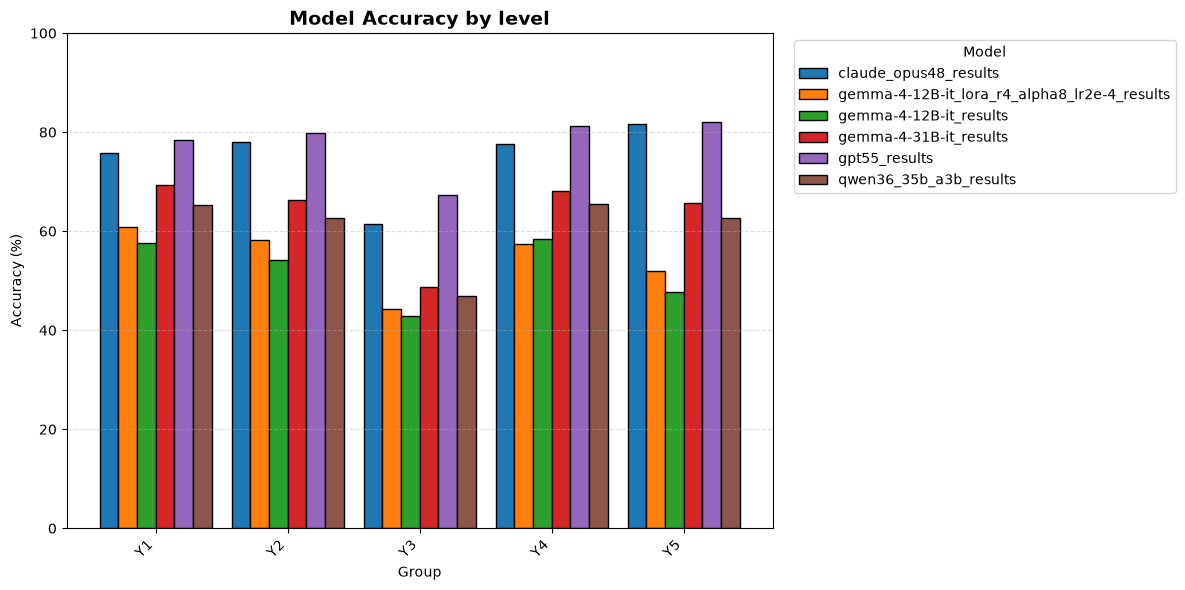

In [2]:
overall_df, grouped_df = summarize_model_accuracies(
    folder="results/",
    group_cols=["level"]
)


Overall accuracy and invalid prediction rate per model:


,model_name,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
6,gpt55_results,78.10%,0.00%,3873,0,4959
0,claude_opus48_results,75.36%,0.02%,3737,1,4959
3,gemma-4-31B-it_results,66.71%,0.46%,3308,23,4959
7,qwen36_35b_a3b_results,63.06%,0.00%,3127,0,4959
1,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,58.26%,0.00%,2889,0,4959
2,gemma-4-12B-it_results,55.17%,1.09%,2736,54,4959
4,gemma4_12b_it_lora_r4_a8_val_5_percent,53.22%,0.00%,306,0,575
5,gemma4_12b_it_val_5_percent,48.24%,0.00%,479,0,993



Accuracy and invalid prediction rate grouped by: ['level']


,model_name,level,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
0,claude_opus48_results,Y1,75.70%,0.03%,2324,1,3070
1,claude_opus48_results,Y2,78.09%,0.00%,759,0,972
2,claude_opus48_results,Y3,61.48%,0.00%,265,0,431
3,claude_opus48_results,Y4,77.66%,0.00%,153,0,197
4,claude_opus48_results,Y5,81.66%,0.00%,236,0,289
5,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y1,60.91%,0.00%,1870,0,3070
6,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y2,58.13%,0.00%,565,0,972
7,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y3,44.32%,0.00%,191,0,431
8,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y4,57.36%,0.00%,113,0,197
9,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,Y5,51.90%,0.00%,150,0,289


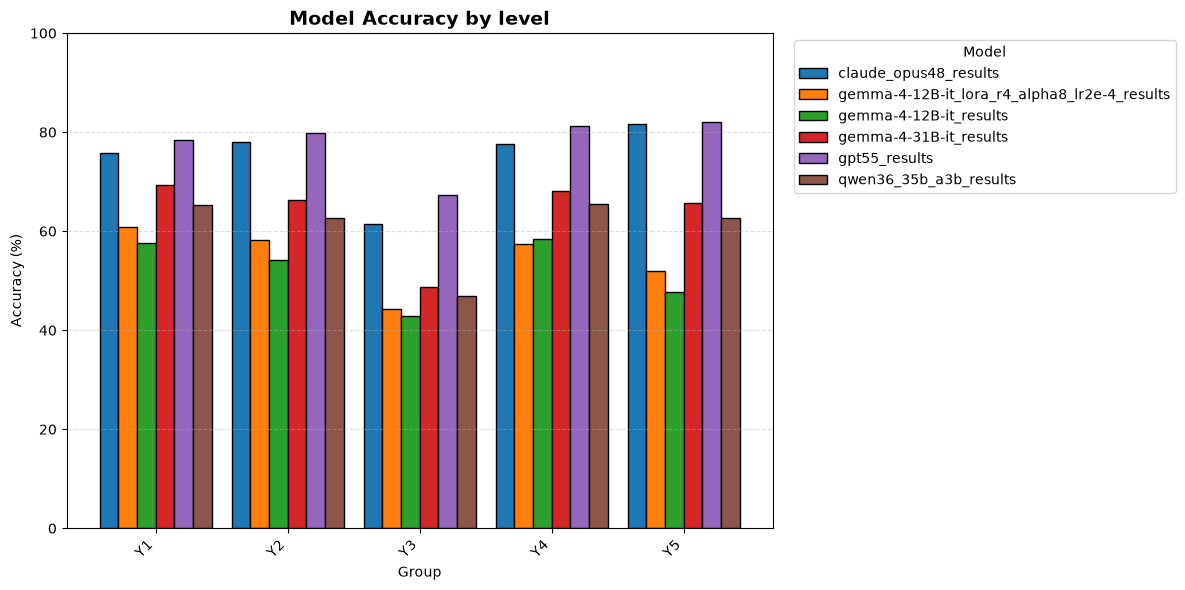


Overall accuracy and invalid prediction rate per model:


,model_name,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
6,gpt55_results,78.10%,0.00%,3873,0,4959
0,claude_opus48_results,75.36%,0.02%,3737,1,4959
3,gemma-4-31B-it_results,66.71%,0.46%,3308,23,4959
7,qwen36_35b_a3b_results,63.06%,0.00%,3127,0,4959
1,gemma-4-12B-it_lora_r4_alpha8_lr2e-4_results,58.26%,0.00%,2889,0,4959
2,gemma-4-12B-it_results,55.17%,1.09%,2736,54,4959
4,gemma4_12b_it_lora_r4_a8_val_5_percent,53.22%,0.00%,306,0,575
5,gemma4_12b_it_val_5_percent,48.24%,0.00%,479,0,993



Accuracy and invalid prediction rate grouped by: ['medical_specialty']


,model_name,medical_specialty,accuracy_percent,invalid_rate_percent,n_correct,n_invalid,n_questions
0,claude_opus48_results,Anatomy,81.05%,0.00%,757,0,934
1,claude_opus48_results,Anesthesia,79.27%,0.00%,65,0,82
2,claude_opus48_results,Biochemistry,78.17%,0.00%,290,0,371
3,claude_opus48_results,Cardiology,84.21%,0.00%,16,0,19
4,claude_opus48_results,Cell Biology,62.33%,0.00%,182,0,292
5,claude_opus48_results,Chemistry,84.15%,0.00%,69,0,82
6,claude_opus48_results,Chest Diseases,80.00%,0.00%,8,0,10
7,claude_opus48_results,Embryology,50.00%,0.00%,3,0,6
8,claude_opus48_results,Emergency Medicine,86.96%,0.00%,20,0,23
9,claude_opus48_results,Gastroenterology,96.55%,0.00%,28,0,29


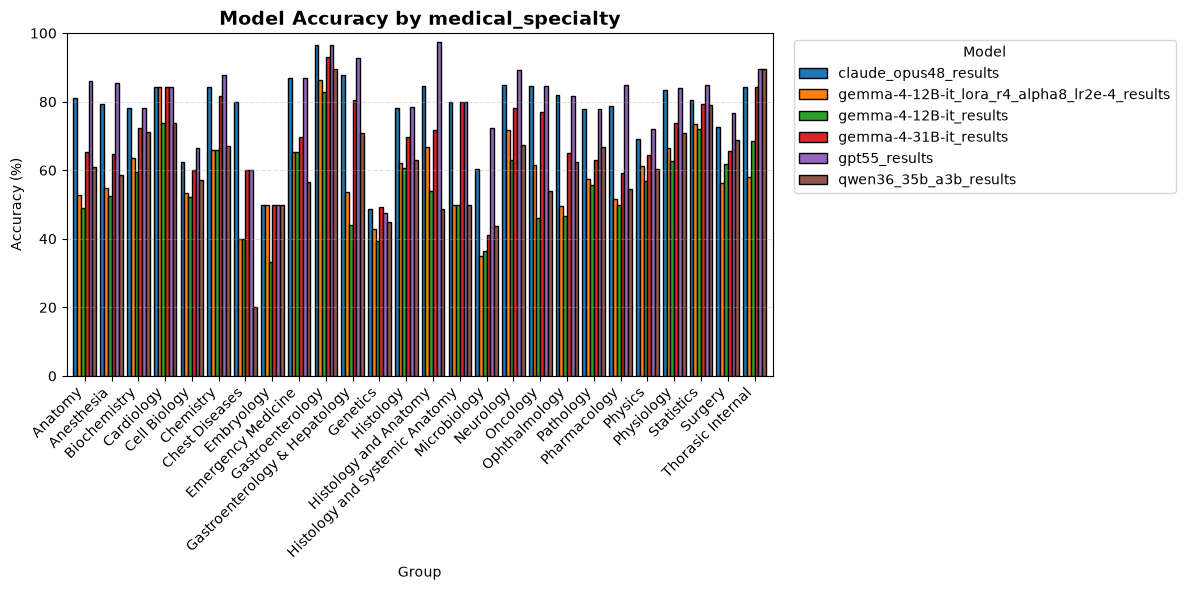

In [3]:
# Accuracy by difficulty level
overall_df, grouped_df = summarize_model_accuracies(
    folder="results/",
    group_cols=["level"]
)

# Accuracy by medical specialty
overall_df, grouped_df = summarize_model_accuracies(
    folder="results/",
    group_cols=["medical_specialty"]
)
